In [ ]:
for file in `ls *.bam*`
do
samtools mpileup -l /data2/chenruipu/data/xulingna/snp/all_snp.bed -q 1 -t DP,AD -m 2 -F 0.002 -uvf /data2/chenruipu/refdata-gex-GRCh38-2024-A/fasta/genome.fa --output $file.vcf $file
done

In [2]:
import vcfpy
import pandas as pd
import os
from pathlib import Path  
root = '/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/'
folder_path=Path(root)
os.chdir(root)
import pandas as pd
all_snp=pd.read_csv('/data2/chenruipu/data/xulingna/snp/all_snp.bed',header=None,sep='\t')
all_snp[['#chrom','pos','ref','alt']]=all_snp[3].str.split(':',expand=True)
all_snp=all_snp[['#chrom','pos','ref','alt']]
for file in folder_path.glob('*.vcf'):
	sample_name=str(file).split('/')[-1].split('list.merge.')[0].split('.bam')[0]
	reader = vcfpy.Reader.from_path(file)
	snp_info=pd.DataFrame(columns=['#chrom','pos',f'{sample_name}_ref',f'{sample_name}_alt'])
	print(str(file))
	for record in reader:
		if len(record.calls[0].data['AD'])>=3:
				new_row={'#chrom':record.CHROM,'pos':str(record.POS),f'{sample_name}_ref':record.calls[0].data['AD'][0],f'{sample_name}_alt':record.calls[0].data['AD'][1]}
				snp_info=snp_info._append(new_row, ignore_index=True)
	all_snp=pd.merge(all_snp,snp_info,on=['#chrom','pos'],how='left')
	all_snp=all_snp.drop_duplicates(subset=['#chrom','pos'])
	all_snp.to_csv('18month_snp_female.tsv', sep='\t',index=False)
		

/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.4-18month_female_output3.list.merge.sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.6-Input1_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.90-18month_female_output2.list.merge.sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.8-Input1_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.85-Input2_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.85-18month_female_output1.list.merge.sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.85-Input3_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.85-Input1_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.8-Input2_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.4-Input1_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.6-18month_female_output2.list.merge.sort.bam.vcf
/data2/chenruipu/data/xulingn

In [2]:
import vcfpy
import pandas as pd
import os
from pathlib import Path  
root = '/data2/chenruipu/data/xulingna/snp/bam/input/0.2_input/'
folder_path=Path(root)
os.chdir(root)
import pandas as pd
all_snp=pd.read_csv('/data2/chenruipu/data/xulingna/snp/all_snp.bed',header=None,sep='\t')
all_snp[['#chrom','pos','ref','alt']]=all_snp[3].str.split(':',expand=True)
all_snp=all_snp[['#chrom','pos','ref','alt']]
for file in folder_path.glob('*.vcf'):
	sample_name=str(file).split('-')[1].split('.merge.')[0].split('.')[0]
	reader = vcfpy.Reader.from_path(file)
	snp_info=pd.DataFrame(columns=['#chrom','pos',f'{sample_name}_ref',f'{sample_name}_alt'])
	for record in reader:
		if len(record.calls[0].data['AD'])>=3:
				new_row={'#chrom':record.CHROM,'pos':str(record.POS),f'{sample_name}_ref':record.calls[0].data['AD'][0],f'{sample_name}_alt':record.calls[0].data['AD'][1]}
				snp_info=snp_info._append(new_row, ignore_index=True)
	all_snp=pd.merge(all_snp,snp_info,on=['#chrom','pos'],how='left')

In [13]:
snp_info=snp_info[(snp_info['REF_COUNT']>0)&(not any(x == 0 for x in snp_info['ALT_COUNT']))&(not any(len(x)>1 for x in snp_info['ALT']))]
snp_info.to_csv('snp_info.tsv',sep='\t')

In [ ]:
snp_info_selected.to_csv('enhancer_gene_TF_selected_11_11.tsv',sep='\t')

In [1]:
import pandas as pd
new = pd.read_csv('M18_female_new_methond_type.csv')
old = pd.read_csv('M18_female_old_methond_type.csv')

In [2]:
diff = pd.merge(new, old, on=['Row.names'], how='outer', indicator=True).query("_merge == 'left_only'")
#diff = pd.merge(new, old, on=['Row.names'], how='outer', indicator=True)
diff['LCF_abs'] = abs(diff['LFC_dif_x'])
diff = diff.sort_values(by = ['LCF_abs'],ascending=False,ignore_index=True)
high80 = diff[['Row.names','LCF_abs']].head(80)
midle40 = diff.loc[range(183,223)][['Row.names','LCF_abs']]
low40 = diff.loc[range(480,520)][['Row.names','LCF_abs']]

In [3]:
diff = pd.merge(new, old, on=['Row.names'], how='outer', indicator=True).query("_merge == 'both'")
#diff = pd.merge(new, old, on=['Row.names'], how='outer', indicator=True)
diff['LCF_abs'] = abs(diff['LFC_dif_x'])
diff = diff.sort_values(by = ['LCF_abs'],ascending=False,ignore_index=True)
both_high20 = diff[['Row.names','LCF_abs']].head(20)
both_midle10 = diff.loc[range(144,154)][['Row.names','LCF_abs']]
both_low10 = diff.loc[range(321,331)][['Row.names','LCF_abs']]

In [4]:
select200 = pd.concat([high80,both_high20,midle40,both_midle10,low40,both_low10])

In [ ]:
snp_bed = pd.DataFrame(columns=['chr','start','end','id'])
for id in list(set(select200['Row.names'])):
	id_bed = id.split(':')
	new_row = pd.DataFrame({'chr':[id_bed[0]],'start':[int(id_bed[1])-50],'end':[int(id_bed[1])+50],'id':id})
	snp_bed=pd.concat([snp_bed,new_row])
snp_bed.to_csv('M18_new_old_select200.bed',sep='\t',index=False,header=False)

In [ ]:
bedtools getfasta -name -fi /data5/chenruipu/data/wangchao/translatomer/Translatomer-main-crp/data/hg38/hg38.fa -bed M18_new_old_select200.bed -fo M18_new_old_select200_ref.fasta

In [ ]:
import pandas as pd 
M18_selected=pd.read_csv('M18_new_old_top30.tsv',sep='\t')

In [5]:
snp_bed = pd.DataFrame(columns=['chr','start','end','id'])
for id in list(set(M18_selected['Row.names'])):
	id_bed = id.split(':')
	new_row = pd.DataFrame({'chr':[id_bed[0]],'start':[int(id_bed[1])-175],'end':[int(id_bed[1])+175],'id':id})
	snp_bed=pd.concat([snp_bed,new_row])
	

In [6]:
snp_bed.to_csv('M18_new_old_top30.bed',sep='\t',index=False,header=False)

In [ ]:
bedtools getfasta -name -fi /data5/chenruipu/data/wangchao/translatomer/Translatomer-main-crp/data/hg38/hg38.fa -bed M18_new_old_top30.bed -fo M18_new_old_top30_ref.fasta
#seqkit subseq /data5/chenruipu/data/wangchao/translatomer/Translatomer-main-crp/data/hg38/hg38.fa --bed M18_new_old_top30.bed > M18_new_old_top30_ref.fasta

In [7]:
from Bio import SeqIO
with open ('M18_new_old_top30_alt.fasta','w') as alt_fasta:
	for record in SeqIO.parse('M18_new_old_top30_ref.fasta','fasta'):
		alt_fasta.write(f'>{record.id}\n')
		alt = str(record.id).split(':')[3]
		new_seq=str(record.seq)[:174]+alt+str(record.seq)[175:]
		alt_fasta.write(f'{new_seq}\n')



In [1]:
from Bio import SeqIO
import pandas as pd
ref_df = pd.DataFrame(columns=['seq_id','seq'])
alt_df = pd.DataFrame(columns=['seq_id','seq'])
for record in SeqIO.parse('snpM18_ref.fasta','fasta'):
	new_row = pd.DataFrame({'seq_id':[record.id],'seq':[record.seq]})
	ref_df=pd.concat([ref_df,new_row])
	alt = str(record.id).split(':')[3]
	new_seq=str(record.seq)[:39]+alt+str(record.seq)[40:]
	new_row = pd.DataFrame({'seq_id':[record.id],'seq':[new_seq]})
	alt_df=pd.concat([alt_df,new_row])

In [2]:
alt_df.to_csv('snpM18_alt.tsv',index=False,header=False,sep='\t')
ref_df.to_csv('snpM18_ref.tsv',index=False,header=False,sep='\t')

In [ ]:
import pandas as pd 
human_tpm=pd.read_csv('/data4/yanwei/02_Project/02_A031_Xu_AAV_STARR_human_capture/02_RNA/03_FeatureCount/all_feature_matrix_TPM_avg.txt',sep='\t',header=None)


In [2]:
import numpy as np
print('snp_coverage')
print('input mean')
print(np.mean(snp_coverage['Input1_sort']+snp_coverage['Input2_sort']+snp_coverage['Input3_sort']))
print('output mean')
print(np.mean(snp_coverage['18month_female_output1']+snp_coverage['18month_female_output2']+snp_coverage['18month_female_output3']))
print('input median')
print(np.median(snp_coverage['Input1_sort']+snp_coverage['Input2_sort']+snp_coverage['Input3_sort']))
print('output median')
print(np.median(snp_coverage['18month_female_output1']+snp_coverage['18month_female_output2']+snp_coverage['18month_female_output3']))

#np.median(snp_variant_coverage['11week_male_output1']+snp_variant_coverage['11week_male_output2']+snp_variant_coverage['11week_male_output3']+snp_variant_coverage['Input1_sort']+snp_variant_coverage['Input2_sort']+snp_variant_coverage['Input3_sort'])

snp_coverage
input mean
2287.530186279644
output mean
3377.7276323075707
input median
1917.0
output median
3053.0


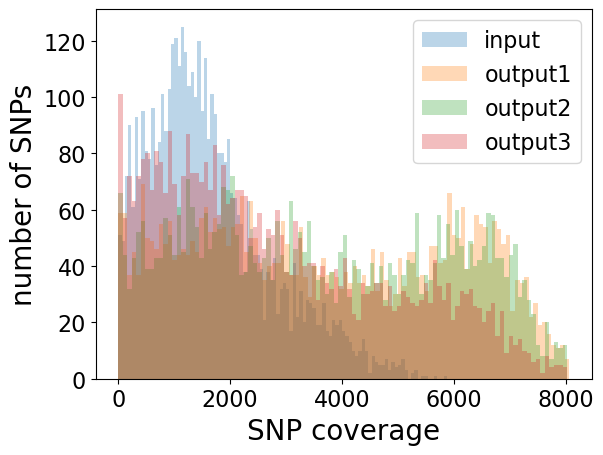

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42   # TrueType（关键）
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['svg.fonttype'] = 'none'  # SVG 也可编辑

plt.rcParams.update({
    'font.size': 18,          # 全局默认字体
    'axes.labelsize': 20,     # 坐标轴标题
    'axes.titlesize': 20,
    'xtick.labelsize': 16,    # x 轴刻度
    'ytick.labelsize': 16,    # y 轴刻度
    'legend.fontsize': 16    # 图例
})

plt.hist(x=snp_coverage['Input1_sort'], bins=100,label='input',alpha=0.3)
#plt.hist(x=snp_coverage['Input2_sort'], bins=100,label='input2',alpha=0.3)
#plt.hist(x=snp_coverage['Input3_sort'], bins=100,label='input3',alpha=0.3)
plt.hist(x=snp_coverage['18month_female_output1'], bins=100,label='output1',alpha=0.3)
plt.hist(x=snp_coverage['18month_female_output2'], bins=100,label='output2',alpha=0.3)
plt.hist(x=snp_coverage['18month_female_output3'], bins=100,label='output3',alpha=0.3)
# plt.hist(x=snp_coverage['18month_male_output1'], bins=100,label='male1',alpha=0.3)
# plt.hist(x=snp_coverage['18month_male_output2'], bins=100,label='male2',alpha=0.3)
# plt.hist(x=snp_coverage['18month_male_output3'], bins=100,label='male3',alpha=0.3)
plt.xlabel('SNP coverage')
plt.ylabel('number of SNPs')
plt.legend(loc="upper right")
plt.savefig('/data2/chenruipu/data/xulingna/snp/SNP_coverage.pdf',dpi = 300,bbox_inches='tight')
plt.show()

In [3]:
import numpy as np
print('snp_coverage')
print('input mean')
print(np.mean(snp_coverage['Input1_sort']+snp_coverage['Input2_sort']+snp_coverage['Input3_sort']))
print('output mean')
print(np.mean(snp_coverage['18month_female_output1']+snp_coverage['18month_female_output2']+snp_coverage['18month_female_output3']))
print('input median')
print(np.median(snp_coverage['Input1_sort']+snp_coverage['Input2_sort']+snp_coverage['Input3_sort']))
print('output median')
print(np.median(snp_coverage['18month_female_output1']+snp_coverage['18month_female_output2']+snp_coverage['18month_female_output3']))

#np.median(snp_variant_coverage['11week_male_output1']+snp_variant_coverage['11week_male_output2']+snp_variant_coverage['11week_male_output3']+snp_variant_coverage['Input1_sort']+snp_variant_coverage['Input2_sort']+snp_variant_coverage['Input3_sort'])

snp_coverage
input mean
2287.530186279644
output mean
3377.7276323075707
input median
1917.0
output median
3053.0


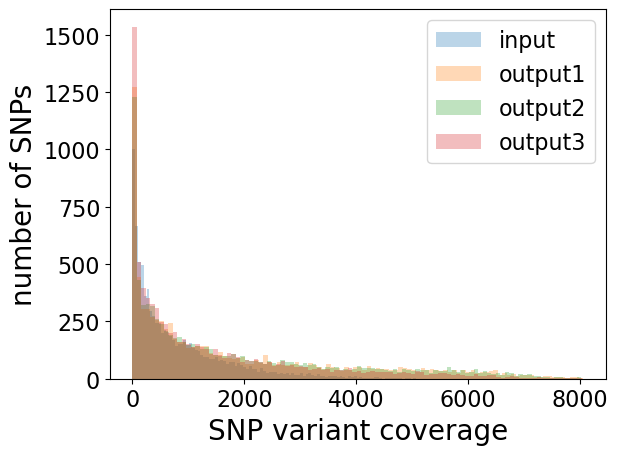

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42   # TrueType（关键）
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['svg.fonttype'] = 'none'  # SVG 也可编辑


plt.hist(x=snp_variant_coverage['Input1_sort'], bins=100,label='input',alpha=0.3)
#plt.hist(x=snp_variant_coverage['Input2_sort'], bins=100,label='input2',alpha=0.3)
#plt.hist(x=snp_variant_coverage['Input3_sort'], bins=100,label='input3',alpha=0.3)
plt.hist(x=snp_variant_coverage['18month_female_output1'], bins=100,label='output1',alpha=0.3)
plt.hist(x=snp_variant_coverage['18month_female_output2'], bins=100,label='output2',alpha=0.3)
plt.hist(x=snp_variant_coverage['18month_female_output3'], bins=100,label='output3',alpha=0.3)
# plt.hist(x=snp_variant_coverage['18month_male_output1'], bins=100,label='male1',alpha=0.3)
# plt.hist(x=snp_variant_coverage['18month_male_output2'], bins=100,label='male2',alpha=0.3)
# plt.hist(x=snp_variant_coverage['18month_male_output3'], bins=100,label='male3',alpha=0.3)
plt.xlabel('SNP variant coverage')
plt.ylabel('number of SNPs')
plt.legend(loc="upper right")
plt.savefig('/data2/chenruipu/data/xulingna/snp/SNP_variant_coverage.pdf',dpi = 300,bbox_inches='tight')
plt.show()

In [12]:
import numpy as np
print('snp_variant_coverage')
print('input mean')
print(np.mean(snp_variant_coverage['Input1_sort']+snp_variant_coverage['Input2_sort']+snp_variant_coverage['Input3_sort']))
print('output mean')
print(np.mean(snp_variant_coverage['18month_female_output1']+snp_variant_coverage['18month_female_output2']+snp_variant_coverage['18month_female_output3']))
print('input median')
print(np.median(snp_variant_coverage['Input1_sort']+snp_variant_coverage['Input2_sort']+snp_variant_coverage['Input3_sort']))
print('output median')
print(np.median(snp_variant_coverage['18month_female_output1']+snp_variant_coverage['18month_female_output2']+snp_variant_coverage['18month_female_output3']))

#np.median(snp_variant_coverage['11week_male_output1']+snp_variant_coverage['11week_male_output2']+snp_variant_coverage['11week_male_output3']+snp_variant_coverage['Input1_sort']+snp_variant_coverage['Input2_sort']+snp_variant_coverage['Input3_sort'])

snp_variant_coverage
input mean
1143.2922869753872
output mean
1688.3809034095405
input median
673.0
output median
947.0


downsample process

In [1]:
import pandas as pd 
import os
os.chdir('/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/')
snp_count = pd.read_csv('18month_snp_female.tsv',sep='\t')

In [2]:
month18_female_output1_count_02 = 5528759
month18_female_output2_count_02 = 5397041
month18_female_output3_count_02 = 3576242
month18_female_output1_count_04 = 11059895
month18_female_output2_count_04 = 10795343
month18_female_output3_count_04 = 7151923
month18_female_output1_count_06 = 16588338
month18_female_output2_count_06 = 16193553
month18_female_output3_count_06 = 10725863
month18_female_output1_count_08 = 22117044
month18_female_output2_count_08 = 21588169
month18_female_output3_count_08 = 14304161
month18_female_output1_count_085 = 23499417
month18_female_output2_count_085 = 22938460
month18_female_output3_count_085 = 15197072
month18_female_output1_count_09 = 24881075
month18_female_output2_count_09 = 24287721
month18_female_output3_count_09 = 16091321
month18_female_output1_count_095 = 26261379
month18_female_output2_count_095 = 25638089
month18_female_output3_count_095 = 16984184
input1_count_02=1885295
input2_count_02=3127926
input3_count_02=3261187
input1_count_04=3767744
input2_count_04=6254240
input3_count_04=6523140
input1_count_06=5650035
input2_count_06=9382095
input3_count_06=9780878
input1_count_08=7533027
input2_count_08=12508005
input3_count_08=13039848
input1_count_085=8004025
input2_count_085=13288957
input3_count_085=13854448
input1_count_09=8475420
input2_count_09=14070821
input3_count_09=14668512
input1_count_095=8947155
input2_count_095=14852225
input3_count_095=15483934


In [4]:
snp_count['Input1_02_ref_scale'] = (snp_count['0.2-Input1_sort_ref']/input1_count_02)*1000000
snp_count['Input1_02_alt_scale'] = (snp_count['0.2-Input1_sort_alt']/input1_count_02)*1000000
snp_count['Input2_02_ref_scale'] = (snp_count['0.2-Input2_sort_ref']/input2_count_02)*1000000
snp_count['Input2_02_alt_scale'] = (snp_count['0.2-Input2_sort_alt']/input2_count_02)*1000000
snp_count['Input3_02_ref_scale'] = (snp_count['0.2-Input3_sort_ref']/input3_count_02)*1000000
snp_count['Input3_02_alt_scale'] = (snp_count['0.2-Input3_sort_alt']/input3_count_02)*1000000
snp_count['Input1_04_ref_scale'] = (snp_count['0.4-Input1_sort_ref']/input1_count_04)*1000000
snp_count['Input1_04_alt_scale'] = (snp_count['0.4-Input1_sort_alt']/input1_count_04)*1000000
snp_count['Input2_04_ref_scale'] = (snp_count['0.4-Input2_sort_ref']/input2_count_04)*1000000
snp_count['Input2_04_alt_scale'] = (snp_count['0.4-Input2_sort_alt']/input2_count_04)*1000000
snp_count['Input3_04_ref_scale'] = (snp_count['0.4-Input3_sort_ref']/input3_count_04)*1000000
snp_count['Input3_04_alt_scale'] = (snp_count['0.4-Input3_sort_alt']/input3_count_04)*1000000
snp_count['Input1_06_ref_scale'] = (snp_count['0.6-Input1_sort_ref']/input1_count_06)*1000000
snp_count['Input1_06_alt_scale'] = (snp_count['0.6-Input1_sort_alt']/input1_count_06)*1000000
snp_count['Input2_06_ref_scale'] = (snp_count['0.6-Input2_sort_ref']/input2_count_06)*1000000
snp_count['Input2_06_alt_scale'] = (snp_count['0.6-Input2_sort_alt']/input2_count_06)*1000000
snp_count['Input3_06_ref_scale'] = (snp_count['0.6-Input3_sort_ref']/input3_count_06)*1000000
snp_count['Input3_06_alt_scale'] = (snp_count['0.6-Input3_sort_alt']/input3_count_06)*1000000
snp_count['Input1_08_ref_scale'] = (snp_count['0.8-Input1_sort_ref']/input1_count_08)*1000000
snp_count['Input1_08_alt_scale'] = (snp_count['0.8-Input1_sort_alt']/input1_count_08)*1000000
snp_count['Input2_08_ref_scale'] = (snp_count['0.8-Input2_sort_ref']/input2_count_08)*1000000
snp_count['Input2_08_alt_scale'] = (snp_count['0.8-Input2_sort_alt']/input2_count_08)*1000000
snp_count['Input3_08_ref_scale'] = (snp_count['0.8-Input3_sort_ref']/input3_count_08)*1000000
snp_count['Input3_08_alt_scale'] = (snp_count['0.8-Input3_sort_alt']/input3_count_08)*1000000
snp_count['Input1_085_ref_scale'] = (snp_count['0.85-Input1_sort_ref']/input1_count_085)*1000000
snp_count['Input1_085_alt_scale'] = (snp_count['0.85-Input1_sort_alt']/input1_count_085)*1000000
snp_count['Input2_085_ref_scale'] = (snp_count['0.85-Input2_sort_ref']/input2_count_085)*1000000
snp_count['Input2_085_alt_scale'] = (snp_count['0.85-Input2_sort_alt']/input2_count_085)*1000000
snp_count['Input3_085_ref_scale'] = (snp_count['0.85-Input3_sort_ref']/input3_count_085)*1000000
snp_count['Input3_085_alt_scale'] = (snp_count['0.85-Input3_sort_alt']/input3_count_085)*1000000
snp_count['Input1_09_ref_scale'] = (snp_count['0.90-Input1_sort_ref']/input1_count_09)*1000000
snp_count['Input1_09_alt_scale'] = (snp_count['0.90-Input1_sort_alt']/input1_count_09)*1000000
snp_count['Input2_09_ref_scale'] = (snp_count['0.90-Input2_sort_ref']/input2_count_09)*1000000
snp_count['Input2_09_alt_scale'] = (snp_count['0.90-Input2_sort_alt']/input2_count_09)*1000000
snp_count['Input3_09_ref_scale'] = (snp_count['0.90-Input3_sort_ref']/input3_count_09)*1000000
snp_count['Input3_09_alt_scale'] = (snp_count['0.90-Input3_sort_alt']/input3_count_09)*1000000
snp_count['Input1_095_ref_scale'] = (snp_count['0.95-Input1_sort_ref']/input1_count_095)*1000000
snp_count['Input1_095_alt_scale'] = (snp_count['0.95-Input1_sort_alt']/input1_count_095)*1000000
snp_count['Input2_095_ref_scale'] = (snp_count['0.95-Input2_sort_ref']/input2_count_095)*1000000
snp_count['Input2_095_alt_scale'] = (snp_count['0.95-Input2_sort_alt']/input2_count_095)*1000000
snp_count['Input3_095_ref_scale'] = (snp_count['0.95-Input3_sort_ref']/input3_count_095)*1000000
snp_count['Input3_095_alt_scale'] = (snp_count['0.95-Input3_sort_alt']/input3_count_095)*1000000
snp_count['month18_female_output1_ref_scale_02'] = (snp_count['0.2-18month_female_output1._ref']/month18_female_output1_count_02)*1000000
snp_count['month18_female_output1_alt_scale_02'] = (snp_count['0.2-18month_female_output1._alt']/month18_female_output1_count_02)*1000000
snp_count['month18_female_output2_ref_scale_02'] = (snp_count['0.2-18month_female_output2._ref']/month18_female_output2_count_02)*1000000
snp_count['month18_female_output2_alt_scale_02'] = (snp_count['0.2-18month_female_output2._alt']/month18_female_output2_count_02)*1000000
snp_count['month18_female_output3_ref_scale_02'] = (snp_count['0.2-18month_female_output3._ref']/month18_female_output3_count_02)*1000000
snp_count['month18_female_output3_alt_scale_02'] = (snp_count['0.2-18month_female_output3._alt']/month18_female_output3_count_02)*1000000
snp_count['month18_female_output1_ref_scale_04'] = (snp_count['0.4-18month_female_output1._ref']/month18_female_output1_count_04)*1000000
snp_count['month18_female_output1_alt_scale_04'] = (snp_count['0.4-18month_female_output1._alt']/month18_female_output1_count_04)*1000000
snp_count['month18_female_output2_ref_scale_04'] = (snp_count['0.4-18month_female_output2._ref']/month18_female_output2_count_04)*1000000
snp_count['month18_female_output2_alt_scale_04'] = (snp_count['0.4-18month_female_output2._alt']/month18_female_output2_count_04)*1000000
snp_count['month18_female_output3_ref_scale_04'] = (snp_count['0.4-18month_female_output3._ref']/month18_female_output3_count_04)*1000000
snp_count['month18_female_output3_alt_scale_04'] = (snp_count['0.4-18month_female_output3._alt']/month18_female_output3_count_04)*1000000
snp_count['month18_female_output1_ref_scale_06'] = (snp_count['0.6-18month_female_output1._ref']/month18_female_output1_count_06)*1000000
snp_count['month18_female_output1_alt_scale_06'] = (snp_count['0.6-18month_female_output1._alt']/month18_female_output1_count_06)*1000000
snp_count['month18_female_output2_ref_scale_06'] = (snp_count['0.6-18month_female_output2._ref']/month18_female_output2_count_06)*1000000
snp_count['month18_female_output2_alt_scale_06'] = (snp_count['0.6-18month_female_output2._alt']/month18_female_output2_count_06)*1000000
snp_count['month18_female_output3_ref_scale_06'] = (snp_count['0.6-18month_female_output3._ref']/month18_female_output3_count_06)*1000000
snp_count['month18_female_output3_alt_scale_06'] = (snp_count['0.6-18month_female_output3._alt']/month18_female_output3_count_06)*1000000
snp_count['month18_female_output1_ref_scale_08'] = (snp_count['0.8-18month_female_output1._ref']/month18_female_output1_count_08)*1000000
snp_count['month18_female_output1_alt_scale_08'] = (snp_count['0.8-18month_female_output1._alt']/month18_female_output1_count_08)*1000000
snp_count['month18_female_output2_ref_scale_08'] = (snp_count['0.8-18month_female_output2._ref']/month18_female_output2_count_08)*1000000
snp_count['month18_female_output2_alt_scale_08'] = (snp_count['0.8-18month_female_output2._alt']/month18_female_output2_count_08)*1000000
snp_count['month18_female_output3_ref_scale_08'] = (snp_count['0.8-18month_female_output3._ref']/month18_female_output3_count_08)*1000000
snp_count['month18_female_output3_alt_scale_08'] = (snp_count['0.8-18month_female_output3._alt']/month18_female_output3_count_08)*1000000
snp_count['month18_female_output1_ref_scale_085'] = (snp_count['0.85-18month_female_output1._ref']/month18_female_output1_count_085)*1000000
snp_count['month18_female_output1_alt_scale_085'] = (snp_count['0.85-18month_female_output1._alt']/month18_female_output1_count_085)*1000000
snp_count['month18_female_output2_ref_scale_085'] = (snp_count['0.85-18month_female_output2._ref']/month18_female_output2_count_085)*1000000
snp_count['month18_female_output2_alt_scale_085'] = (snp_count['0.85-18month_female_output2._alt']/month18_female_output2_count_085)*1000000
snp_count['month18_female_output3_ref_scale_085'] = (snp_count['0.85-18month_female_output3._ref']/month18_female_output3_count_085)*1000000
snp_count['month18_female_output3_alt_scale_085'] = (snp_count['0.85-18month_female_output3._alt']/month18_female_output3_count_085)*1000000
snp_count['month18_female_output1_ref_scale_09'] = (snp_count['0.90-18month_female_output1._ref']/month18_female_output1_count_09)*1000000
snp_count['month18_female_output1_alt_scale_09'] = (snp_count['0.90-18month_female_output1._alt']/month18_female_output1_count_09)*1000000
snp_count['month18_female_output2_ref_scale_09'] = (snp_count['0.90-18month_female_output2._ref']/month18_female_output2_count_09)*1000000
snp_count['month18_female_output2_alt_scale_09'] = (snp_count['0.90-18month_female_output2._alt']/month18_female_output2_count_09)*1000000
snp_count['month18_female_output3_ref_scale_09'] = (snp_count['0.90-18month_female_output3._ref']/month18_female_output3_count_09)*1000000
snp_count['month18_female_output3_alt_scale_09'] = (snp_count['0.90-18month_female_output3._alt']/month18_female_output3_count_09)*1000000
snp_count['month18_female_output1_ref_scale_095'] = (snp_count['0.95-18month_female_output1._ref']/month18_female_output1_count_095)*1000000
snp_count['month18_female_output1_alt_scale_095'] = (snp_count['0.95-18month_female_output1._alt']/month18_female_output1_count_095)*1000000
snp_count['month18_female_output2_ref_scale_095'] = (snp_count['0.95-18month_female_output2._ref']/month18_female_output2_count_095)*1000000
snp_count['month18_female_output2_alt_scale_095'] = (snp_count['0.95-18month_female_output2._alt']/month18_female_output2_count_095)*1000000
snp_count['month18_female_output3_ref_scale_095'] = (snp_count['0.95-18month_female_output3._ref']/month18_female_output3_count_095)*1000000
snp_count['month18_female_output3_alt_scale_095'] = (snp_count['0.95-18month_female_output3._alt']/month18_female_output3_count_095)*1000000

In [5]:
snp_count.to_csv('M18_snp_female_downsample.tsv', sep='\t',index=False)

previous and current strategies overlap

In [36]:
import pandas as pd 
old = pd.read_csv('M18_female_old_methond_type.csv')
new=pd.read_csv('M18_female_new_methond_type.csv')


In [42]:
#old = old[(old['log2FoldChange.y']>0.585)|(old['log2FoldChange.x']>0.585)]
new = new[((new['log2FoldChange.y']>0.585)&(new['padj.y']<0.05))|((new['log2FoldChange.x']>0.585)&(new['padj.x']<0.05))]

In [46]:
new = new[new['Row.names'].isin(snp_ingwas_list)]

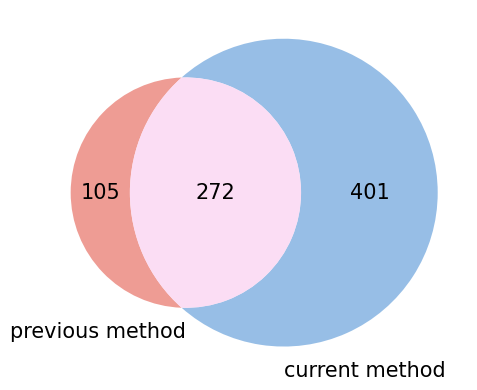

In [44]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# 三个示例列表
A = old['Row.names'].to_list()
B = new['Row.names'].to_list()


# 绘制二集合韦恩图
plt.figure(figsize=(5, 5))
venn = venn2(
    [set(A)&set(snp_ingwas_list), set(B)&set(snp_ingwas_list)],
    set_labels=('previous method', 'current method'),
    set_colors=('#EA8379', '#7DAEE0'),
    alpha=0.8
)

# 美化样式
for text in venn.set_labels:
    text.set_fontsize(15)
for text in venn.subset_labels:
    if text:  # 避免空区域报错
        text.set_fontsize(15)

plt.title("", fontsize=11)
plt.tight_layout()

# ✅ 保存为 PDF 文件
plt.savefig("old_new_method_overlap.pdf", format="pdf", bbox_inches="tight")

plt.show()
